In [1]:
import torch
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Paths
FS_OUTPUT = Path("E:/Oasis3/FastSurfer_output")
COHORT_CSV = Path("E:/Oasis3/thesis_cohort_final.csv")

# Load cohort
cohort = pd.read_csv(COHORT_CSV)
print(f"\nCohort: {len(cohort)} subjects")
print(f"Converters: {cohort.outcome_label.sum()}")
print(f"Stable CN: {(cohort.outcome_label==0).sum()}")

# Check first subject files exist
first = cohort.iloc[0]
seg_file = FS_OUTPUT / first['mri_session'] / 'mri' / 'aparc.DKTatlas+aseg.deep.mgz'
orig_file = FS_OUTPUT / first['mri_session'] / 'mri' / 'orig.mgz'
print(f"\nFirst subject: {first['mri_session']}")
print(f"Seg file exists: {seg_file.exists()}")
print(f"Orig file exists: {orig_file.exists()}")

PyTorch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 3070 Ti

Cohort: 210 subjects
Converters: 107
Stable CN: 103

First subject: OAS30564_MR_d2808
Seg file exists: True
Orig file exists: True


In [29]:
def extract_roi_cropped_final(session_id, roi_size=(64, 64, 64)):
    seg_path = f"{FS_OUTPUT}/{session_id}/mri/aparc.DKTatlas+aseg.deep.mgz"
    orig_path = f"{FS_OUTPUT}/{session_id}/mri/orig.mgz"

    seg_data = nib.load(seg_path).get_fdata()
    orig_data = nib.load(orig_path).get_fdata()

    rois = {}
    for roi_name, label_id in ROI_INFO.items():
        mask = (seg_data == label_id)
        roi_vol = orig_data * mask

        # Tight crop
        coords = np.where(mask)
        if len(coords[0]) == 0:
            rois[roi_name] = np.zeros(roi_size, dtype=np.float32)
            continue

        z1, z2 = coords[0].min(), coords[0].max()
        y1, y2 = coords[1].min(), coords[1].max()
        x1, x2 = coords[2].min(), coords[2].max()

        pad = 3
        z1 = max(0, z1-pad)
        z2 = min(seg_data.shape[0]-1, z2+pad)
        y1 = max(0, y1-pad)
        y2 = min(seg_data.shape[1]-1, y2+pad)
        x1 = max(0, x1-pad)
        x2 = min(seg_data.shape[2]-1, x2+pad)

        cropped = roi_vol[z1:z2+1, y1:y2+1, x1:x2+1]

        # Z-score normalise
        roi_voxels = cropped[cropped != 0]
        if len(roi_voxels) > 0 and roi_voxels.std() > 0:
            cropped = np.where(cropped != 0,
                              (cropped - roi_voxels.mean()) / roi_voxels.std(),
                              0)

        # Resize to target size
        zoom_factors = [t/s for t, s in zip(roi_size, cropped.shape)]
        resized = zoom(cropped, zoom_factors, order=1)
        rois[roi_name] = resized.astype(np.float32)

    return rois

print("extract_roi_cropped_final defined!")

extract_roi_cropped_final defined!


Shape: (6, 64, 64, 64)


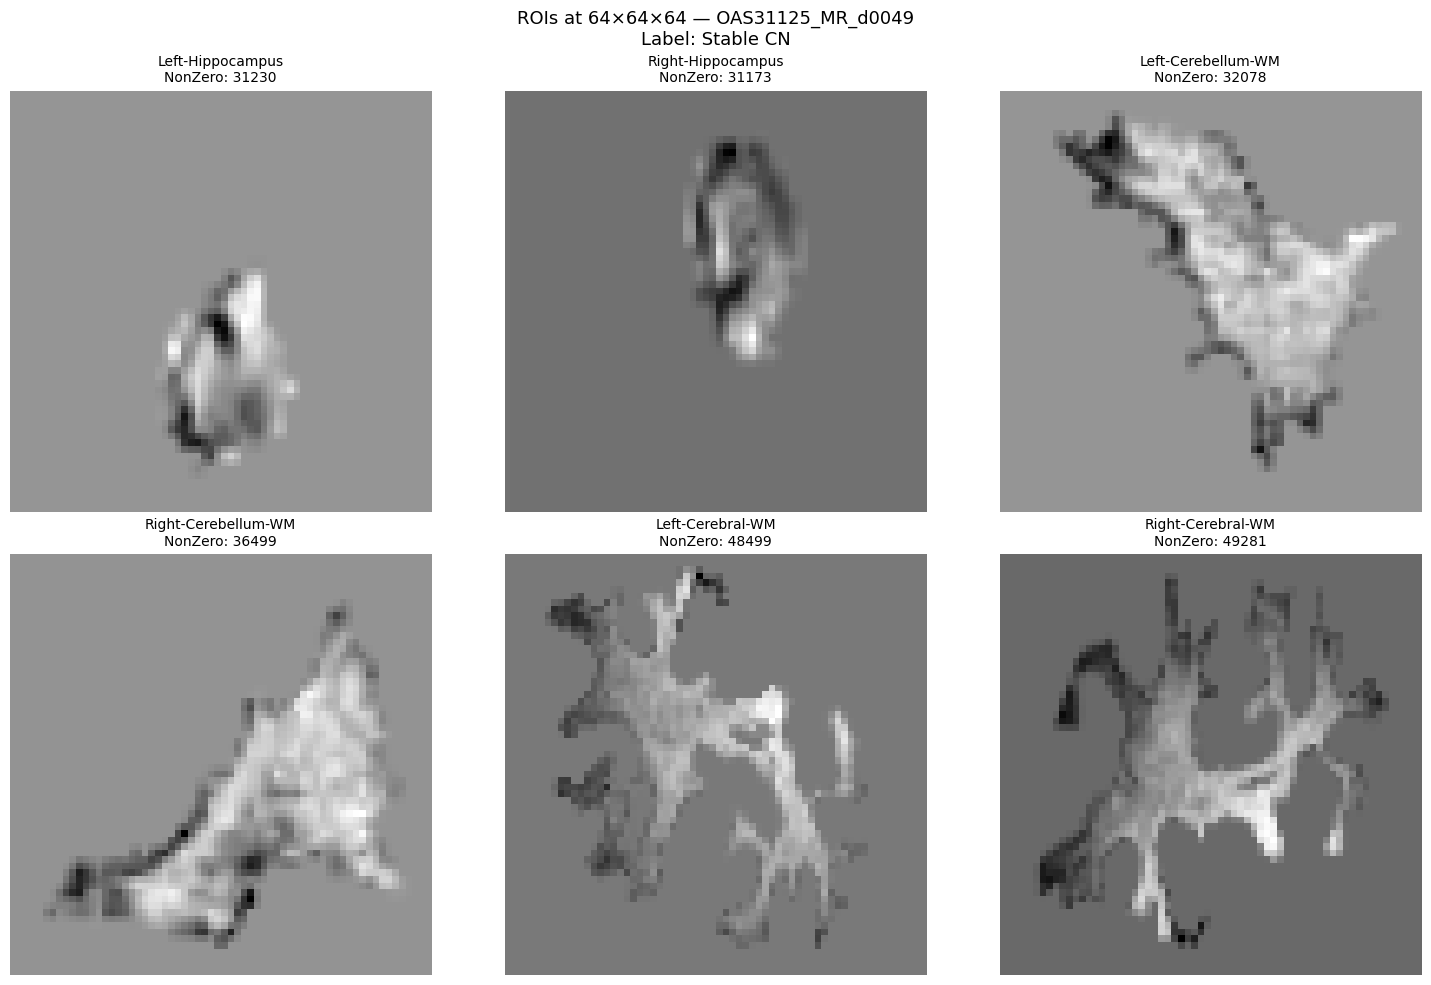

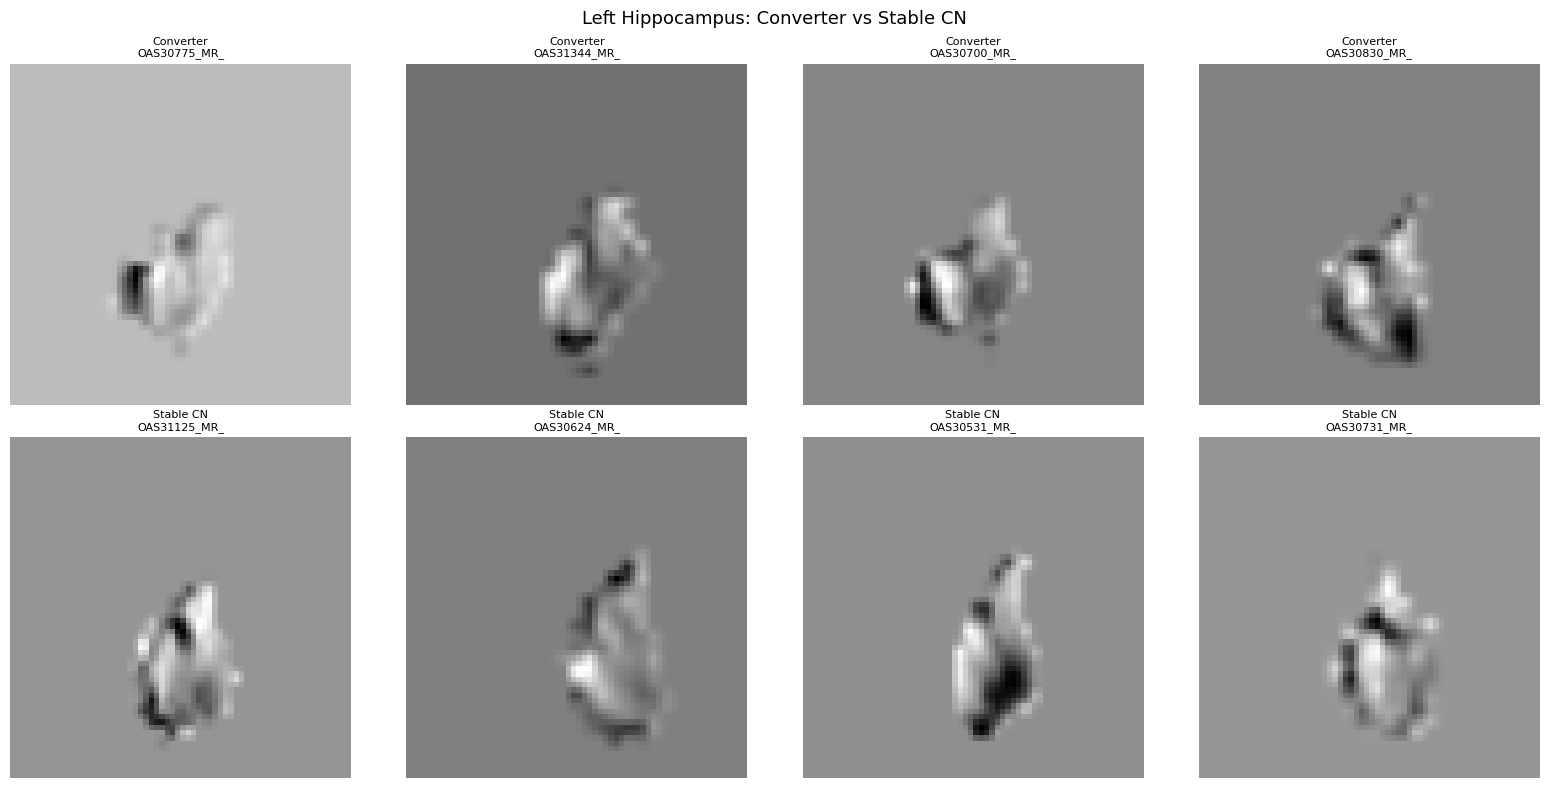

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Load one subject from cache
sample = np.load(f"{CACHE_DIR_ROI64}/{X_val[0]}.npy")
print(f"Shape: {sample.shape}")  # (6, 64, 64, 64)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, roi_name in enumerate(ROI_NAMES):
    ax = axes[idx//3, idx%3]
    roi_vol = sample[idx]  # (64, 64, 64)
    mid = roi_vol.shape[2] // 2
    ax.imshow(roi_vol[:, :, mid], cmap='gray')
    nz = (roi_vol != 0).sum()
    ax.set_title(f'{roi_name}\nNonZero: {nz}', fontsize=10)
    ax.axis('off')

plt.suptitle(f'ROIs at 64×64×64 — {X_val[0]}\nLabel: {"Converter" if y_val[0]==1 else "Stable CN"}', fontsize=13)
plt.tight_layout()
plt.show()

# Also compare converter vs stable CN side by side for hippocampus
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
conv_idx = np.where(y_val == 1)[0][:4]
cn_idx = np.where(y_val == 0)[0][:4]

for i in range(4):
    # Converter hippocampus
    conv_sample = np.load(f"{CACHE_DIR_ROI64}/{X_val[conv_idx[i]]}.npy")
    axes2[0, i].imshow(conv_sample[0, :, :, 32], cmap='gray')
    axes2[0, i].set_title(f'Converter\n{X_val[conv_idx[i]][:12]}', fontsize=8)
    axes2[0, i].axis('off')

    # Stable CN hippocampus
    cn_sample = np.load(f"{CACHE_DIR_ROI64}/{X_val[cn_idx[i]]}.npy")
    axes2[1, i].imshow(cn_sample[0, :, :, 32], cmap='gray')
    axes2[1, i].set_title(f'Stable CN\n{X_val[cn_idx[i]][:12]}', fontsize=8)
    axes2[1, i].axis('off')

plt.suptitle('Left Hippocampus: Converter vs Stable CN', fontsize=13)
plt.tight_layout()
plt.show()

In [47]:
import numpy as np
from scipy.ndimage import rotate
import random

CACHE_DIR_ROI64_AUG = "D:/mamba_model/preprocessed_cache_roi64_aug"

def augment_roi_simple(roi_array, seed):
    """Simple rotation + flip augmentation"""
    np.random.seed(seed)
    random.seed(seed)
    
    augmented = roi_array.copy()
    
    # Random rotation
    angle = np.random.uniform(-15, 15)
    for i in range(6):
        augmented[i] = rotate(augmented[i], angle, reshape=False, 
                             mode='constant', cval=0)
    
    # Random flips
    if np.random.random() > 0.5:
        augmented = augmented[:, ::-1, :, :].copy()
    if np.random.random() > 0.5:
        augmented = augmented[:, :, ::-1, :].copy()
    
    return augmented.astype(np.float32)

print("Re-creating simple augmentation files...")
failed = []
for seed in [1, 101, 42]:
    for i, session_id in enumerate(X_train):
        save_path = f"{CACHE_DIR_ROI64_AUG}/{session_id}_aug{seed}.npy"
        try:
            orig = np.load(f"{CACHE_DIR_ROI64_AUG}/{session_id}_orig.npy")
            augmented = augment_roi_simple(orig, seed)
            np.save(save_path, augmented)
        except Exception as e:
            print(f"  FAILED {session_id}: {e}")
            failed.append(session_id)
    print(f"  Seed {seed} done")

print(f"\nDone! Failed: {len(failed)}")

# Verify aug files are different from orig
orig_sample

Re-creating simple augmentation files...
  Seed 1 done
  Seed 101 done
  Seed 42 done

Done! Failed: 0


NameError: name 'orig_sample' is not defined

In [48]:
orig_sample = np.load(f"{CACHE_DIR_ROI64_AUG}/{X_train[0]}_orig.npy")
aug_sample  = np.load(f"{CACHE_DIR_ROI64_AUG}/{X_train[0]}_aug1.npy")
print(f"Verification:")
print(f"Orig mean: {orig_sample.mean():.6f}")
print(f"Aug1 mean: {aug_sample.mean():.6f}")
print(f"Different: {not np.allclose(orig_sample, aug_sample)}")
print(f"Difference: {np.abs(orig_sample - aug_sample).mean():.6f}")

Verification:
Orig mean: 0.000006
Aug1 mean: 0.000006
Different: True
Difference: 0.119713
